In [2]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=sns.load_dataset('iris')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df=df[['sepal_length','petal_length','species']]

In [8]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [9]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [11]:
clf=LogisticRegression(multi_class='multinomial')

In [12]:
clf.fit(x_train,y_train)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [13]:
y_pred=clf.predict(x_test)

In [14]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.88      0.93         8
           2       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



In [16]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [17]:
#prediction
query=np.array([[3.4,2.7]])
clf.predict_proba(query)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [18]:
clf.predict(query)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'softmax on Iris')

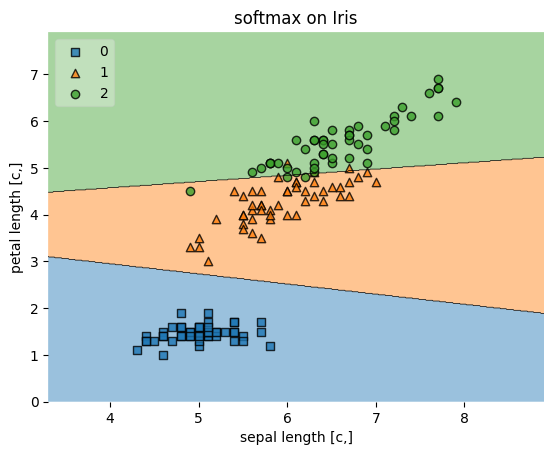

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.values,clf,legend=2)

plt.xlabel('sepal length [c,]')
plt.ylabel('petal length [c,]')
plt.title("softmax on Iris")

                Practice on titanic

In [20]:
titanic=sns.load_dataset('titanic')

In [21]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [23]:
titanic['age'].fillna(titanic['age'].median(), inplace=True)  # Fill missing ages with median
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)  # Fill missing embarked with mode

C:\Users\niraj\AppData\Local\Temp\ipykernel_62056\3884188929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)  # Fill missing ages with median
C:\Users\niraj\AppData\Local\Temp\ipykernel_62056\3884188929.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

In [24]:
titanic.dropna(subset=['survived'],inplace=True)

In [25]:
X = titanic[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']]
y = titanic['survived']

In [26]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline

In [28]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['pclass', 'age', 'sibsp', 'parch', 'fare']),
        ('cat',OneHotEncoder(drop='first'),['sex','embarked'])
    ]
)

In [29]:
pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression(max_iter=200))
    ]
)

In [30]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'embarked'])])),
                ('classifier', LogisticRegression(max_iter=200))])

In [31]:
x_train

,pclass,age,sibsp,parch,fare,sex,embarked
30,1,40.0,0,0,27.7208,male,C
10,3,4.0,1,1,16.7000,female,S
873,3,47.0,0,0,9.0000,male,S
182,3,9.0,4,2,31.3875,male,S
876,3,20.0,0,0,9.8458,male,S
...,...,...,...,...,...,...,...
534,3,30.0,0,0,8.6625,female,S
584,3,28.0,0,0,8.7125,male,C
493,1,71.0,0,0,49.5042,male,C
527,1,28.0,0,0,221.7792,male,S


In [32]:
y_pred=pipeline.predict(x_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7821229050279329
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82       100
           1       0.84      0.62      0.72        79

    accuracy                           0.78       179
   macro avg       0.80      0.77      0.77       179
weighted avg       0.79      0.78      0.78       179



C:\Users\niraj\AppData\Local\Temp\ipykernel_62056\1855202495.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)  # Fill missing ages with median
C:\Users\niraj\AppData\Local\Temp\ipykernel_62056\1855202495.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

Accuracy: 0.7039106145251397
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.85      0.77       105
           1       0.70      0.50      0.58        74

    accuracy                           0.70       179
   macro avg       0.70      0.67      0.68       179
weighted avg       0.70      0.70      0.69       179



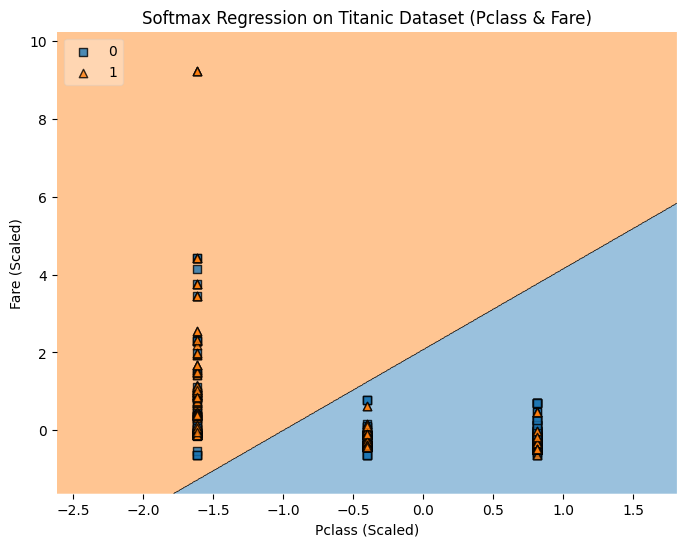

In [34]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# Load the Titanic dataset from Seaborn
titanic = sns.load_dataset('titanic')

# Drop rows with missing target values (survived column)
titanic.dropna(subset=['survived'], inplace=True)

# Preprocess the data (handle missing values for age, embarked)
titanic['age'].fillna(titanic['age'].median(), inplace=True)  # Fill missing ages with median
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)  # Fill missing embarked with mode

# Select features (X) and target (y)
X = titanic[['pclass', 'fare']]  # Selecting only two features: pclass and fare
y = titanic['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the logistic regression model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = clf.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot decision regions using mlxtend
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train_scaled, y_train.values, clf=clf, legend=2)

# Customize the plot
plt.xlabel('Pclass (Scaled)')
plt.ylabel('Fare (Scaled)')
plt.title("Softmax Regression on Titanic Dataset (Pclass & Fare)")
plt.show()
